# Figures for the Corporate Chapter of the Report SOTJ 2024

## 0. Load packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# View all columns
pd.set_option('display.max_columns', None)
# Show me numbers in non-scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

## Step 1. Call the datasets and transform slightly the Terms of Reference Dataset

In [2]:
sotj_2021_data = pd.read_csv('../output/tables/2024/Final_Full_CBCR_Datasets/SOTJ_sample_countries_2021.csv')

tor_vote = pd.read_excel('../output/tables/2024/TOR_Vote_Population.xlsx')

# Drop TOR_vote_dummy column
tor_vote = tor_vote.drop(columns=['TOR_vote_dummy'])
# Drop rows with NaN values
tor_vote = tor_vote.dropna()
# Rename iso3 as iso_partner
tor_vote = tor_vote.rename(columns={'iso3':'iso_partner'})

tor_vote


,iso_partner,population,TOR_vote
0,AGO,36684202.00,Yes
1,AZE,10112555.00,Yes
2,BDI,13238559.00,Yes
3,BFA,23251485.00,Yes
4,BGD,172954319.00,Yes
...,...,...,...
157,SVN,2120937.00,Abstention
158,SWE,10536632.00,Abstention
159,TTO,1534937.00,Abstention
160,TUR,85326000.00,Abstention


## Step 2. Merge the 2 dataframes and correct the vote for the UK and US dependencies

In [3]:
# Merge the two dataframes
sotj_tor_data_2021 = sotj_2021_data.merge(tor_vote, on='iso_partner', how='left')

# Keep iso_partner, ukt, population, tax_revenue_loss_caused_pct_of_total and TOR_vote
sotj_tor_data_2021 = sotj_tor_data_2021[['iso_partner', 'ukt', 'population', 'tax_revenue_loss_caused_usd', 'tax_revenue_loss_caused_pct_of_total', 'TOR_vote']]

# If ukt = 1, make TOR_vote = No
sotj_tor_data_2021['TOR_vote'] = sotj_tor_data_2021.apply(lambda x: 'No' if x['ukt'] == 1 else x['TOR_vote'], axis=1)
sotj_tor_data_2021['TOR_vote'] = sotj_tor_data_2021.apply(lambda x: 'No' if x['ukt'] == 1 else x['TOR_vote'], axis=1)

# If iso_partner is PRI, GUM, VIR and ASM, make TOR_vote = No
sotj_tor_data_2021['TOR_vote'] =  sotj_tor_data_2021.apply(lambda x: 'No' if x['iso_partner'] in ['PRI', 'GUM', 'VIR', 'ASM'] else x['TOR_vote'], axis=1)

# Create a new column with the sum of tax_revenue_loss_caused_usd
sotj_tor_data_2021['tax_revenue_loss_caused_usd'].sum()

# Add a new column name sum_tax_revenue_loss_caused_usd which is the sum of tax_revenue_loss_caused_usd
sotj_tor_data_2021['sum_tax_revenue_loss_caused_usd'] = sotj_tor_data_2021['tax_revenue_loss_caused_usd'].sum()

sotj_tor_data_2021


,iso_partner,ukt,population,tax_revenue_loss_caused_usd,tax_revenue_loss_caused_pct_of_total,TOR_vote,sum_tax_revenue_loss_caused_usd
0,ABW,0.00,NaN,0.00,0.00,NaN,347578.91
1,AFG,0.00,NaN,0.75,0.00,NaN,347578.91
2,AGO,0.00,36684202.00,80.66,0.00,Yes,347578.91
3,AIA,1.00,NaN,0.00,0.00,No,347578.91
4,ALB,0.00,2745972.00,1.05,0.00,Abstention,347578.91
...,...,...,...,...,...,...,...
206,XKV,0.00,NaN,0.83,0.00,NaN,347578.91
207,YEM,0.00,34449825.00,0.50,0.00,Yes,347578.91
208,ZAF,0.00,60414495.00,4621.60,0.01,Yes,347578.91
209,ZMB,0.00,20569737.00,0.00,0.00,Yes,347578.91


## Step 3. Create a dataset with GDP and Population for 2021

In [4]:
gdp_population_2021 = pd.read_csv('../data/final/2024/cbcr_main_no_imputation_allsubgroupsonly.csv')

# Keep if year == 2021
gdp_population_2021 = gdp_population_2021[gdp_population_2021['year'] == 2021]

# Keep only the columns we need: iso_parent, iso_partner, gdp, gdp_current_usd
gdp_population_2021 = gdp_population_2021[['iso_partner', 'gdp_current_usd', 'population']]

# Sort by iso_partner
gdp_population_2021 = gdp_population_2021.sort_values(by='iso_partner')

# Drop duplicates
gdp_population_2021 = gdp_population_2021.drop_duplicates()

gdp_population_2021

,iso_partner,gdp_current_usd,population
765,A,NaN,NaN
3578,ABW,3103184101.51,106537.00
4148,AFG,14266499429.87,40099462.00
12236,AGO,66505129987.72,34503774.00
797,AIA,380000000.00,14500.00
...,...,...,...
4948,XKV,9420000000.00,1786038.00
13186,YEM,26588738327.26,32981641.00
12228,ZAF,420117812466.04,59392255.00
9953,ZMB,22096416932.01,19473125.00


## Step 4. Merge the 2 datasets above

In [5]:
# Merge the two dataframes
data_figure_conclusion = sotj_tor_data_2021.merge(gdp_population_2021, on='iso_partner', how='left')

# Drop population_x column
data_figure_conclusion = data_figure_conclusion.drop(columns=['population_x'])

# Rename population_y as population
data_figure_conclusion = data_figure_conclusion.rename(columns={'population_y':'population'})

# Divide gdp_current_usd by 1000000 to get gdp in millions
data_figure_conclusion['gdp_current_usd'] = data_figure_conclusion['gdp_current_usd'] / 1000000

data_figure_conclusion

,iso_partner,ukt,tax_revenue_loss_caused_usd,tax_revenue_loss_caused_pct_of_total,TOR_vote,sum_tax_revenue_loss_caused_usd,gdp_current_usd,population
0,ABW,0.00,0.00,0.00,NaN,347578.91,3103.18,106537.00
1,AFG,0.00,0.75,0.00,NaN,347578.91,14266.50,40099462.00
2,AGO,0.00,80.66,0.00,Yes,347578.91,66505.13,34503774.00
3,AIA,1.00,0.00,0.00,No,347578.91,380.00,14500.00
4,ALB,0.00,1.05,0.00,Abstention,347578.91,17930.57,2811666.00
...,...,...,...,...,...,...,...,...
206,XKV,0.00,0.83,0.00,NaN,347578.91,9420.00,1786038.00
207,YEM,0.00,0.50,0.00,Yes,347578.91,26588.74,32981641.00
208,ZAF,0.00,4621.60,0.01,Yes,347578.91,420117.81,59392255.00
209,ZMB,0.00,0.00,0.00,Yes,347578.91,22096.42,19473125.00


## Step 5. Generate the dataset by TOR Voting Groups

In [6]:
# Aggregrate killer_graph_data by TOR_vote
voting_groups_TOR = data_figure_conclusion.groupby('TOR_vote').agg(
    population=('population', 'sum'),
    gdp_current_usd=('gdp_current_usd', 'sum'),
    tax_revenue_loss_caused_usd=('tax_revenue_loss_caused_usd', 'sum'),
).reset_index() # Reset the index to make TOR_vote a column 

# Add a new column name sum_tax_revenue_loss_caused_usd which is the sum of tax_revenue_loss_caused_usd
voting_groups_TOR['sum_tax_revenue_loss_caused_usd'] = voting_groups_TOR['tax_revenue_loss_caused_usd'].sum()

# Generate new column which is tax_revenue_loss_caused_usd divided by sum_tax_revenue_loss_caused_usd
voting_groups_TOR['share_tax_revenue_loss_caused_usd_pct'] = voting_groups_TOR['tax_revenue_loss_caused_usd'] / voting_groups_TOR['sum_tax_revenue_loss_caused_usd']

# Generate new column which is population divided by sum of population
voting_groups_TOR['share_population_pct'] = voting_groups_TOR['population'] / voting_groups_TOR['population'].sum()

# Generate new column which is gdp_current_usd divided by sum of gdp_current_usd
voting_groups_TOR['share_gdp_current_usd_pct'] = voting_groups_TOR['gdp_current_usd'] / voting_groups_TOR['gdp_current_usd'].sum()

voting_groups_TOR


,TOR_vote,population,gdp_current_usd,tax_revenue_loss_caused_usd,sum_tax_revenue_loss_caused_usd,share_tax_revenue_loss_caused_usd_pct,share_population_pct,share_gdp_current_usd_pct
0,Abstention,669715764.00,21113083.64,122665.37,301499.63,0.41,0.09,0.22
1,No,659028331.00,38054247.45,116482.18,301499.63,0.39,0.09,0.40
2,Yes,6278434338.00,36386049.37,62352.09,301499.63,0.21,0.83,0.38


## Step 6. Filter necessary data

In [7]:
# Keep in voting_groups_TOR: TOR_vote, share_population_pct, share_tax_revenue_loss_caused_usd_pct
voting_groups_TOR = voting_groups_TOR[['TOR_vote', 'share_population_pct', 'share_tax_revenue_loss_caused_usd_pct']]

voting_groups_TOR


,TOR_vote,share_population_pct,share_tax_revenue_loss_caused_usd_pct
0,Abstention,0.09,0.41
1,No,0.09,0.39
2,Yes,0.83,0.21


## Step 7. Build the Figure

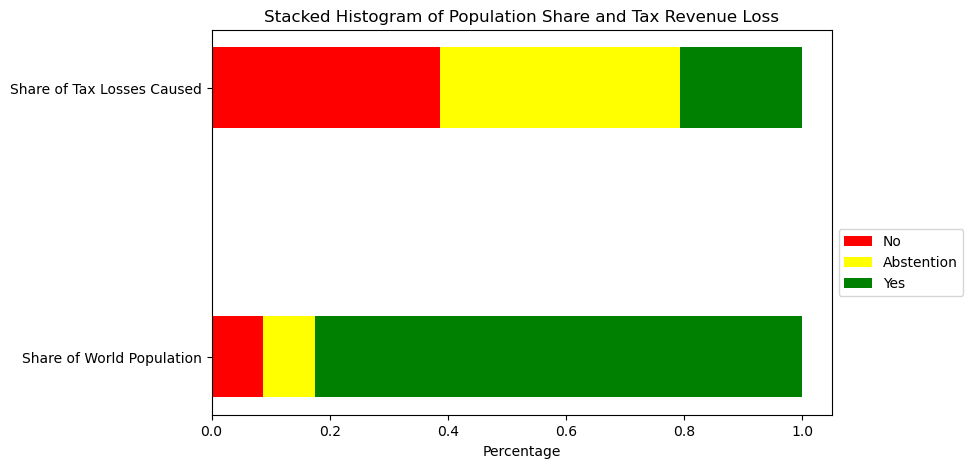

In [8]:
data_graph = voting_groups_TOR.set_index('TOR_vote').loc[['No', 'Abstention', 'Yes']]

# Colors dictionary
colors = {'No': 'red', 'Abstention': 'yellow', 'Yes': 'green'}

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

# Plotting the first column: share_population_pct
ax.barh(y=0, width=data_graph['share_population_pct']['No'], color=colors['No'], label='No', height=0.3)
ax.barh(y=0, width=data_graph['share_population_pct']['Abstention'], color=colors['Abstention'],
    left=data_graph['share_population_pct']['No'], label='Abstention', height=0.3)
ax.barh(y=0, width=data_graph['share_population_pct']['Yes'], color=colors['Yes'],
    left=data_graph['share_population_pct']['No'] + data_graph['share_population_pct']['Abstention'], label='Yes', height=0.3)

# Plotting the second column: share_tax_revenue_loss_caused_usd_pct
ax.barh(y=1, width=data_graph['share_tax_revenue_loss_caused_usd_pct']['No'], color=colors['No'], height=0.3)
ax.barh(y=1, width=data_graph['share_tax_revenue_loss_caused_usd_pct']['Abstention'], color=colors['Abstention'],
    left=data_graph['share_tax_revenue_loss_caused_usd_pct']['No'], height=0.3)
ax.barh(y=1, width=data_graph['share_tax_revenue_loss_caused_usd_pct']['Yes'], color=colors['Yes'],
    left=data_graph['share_tax_revenue_loss_caused_usd_pct']['No'] + data_graph['share_tax_revenue_loss_caused_usd_pct']['Abstention'], height=0.3)

# Labels and legend
ax.set_yticks([0, 1])
ax.set_yticklabels(['Share of World Population', 'Share of Tax Losses Caused'])
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5), title="", labels=['No', 'Abstention', 'Yes'])

# Show plot
plt.xlabel('Percentage')
plt.title('Stacked Histogram of Population Share and Tax Revenue Loss')
plt.show()

## Figures we tried, and were not good enough to transmit the message.

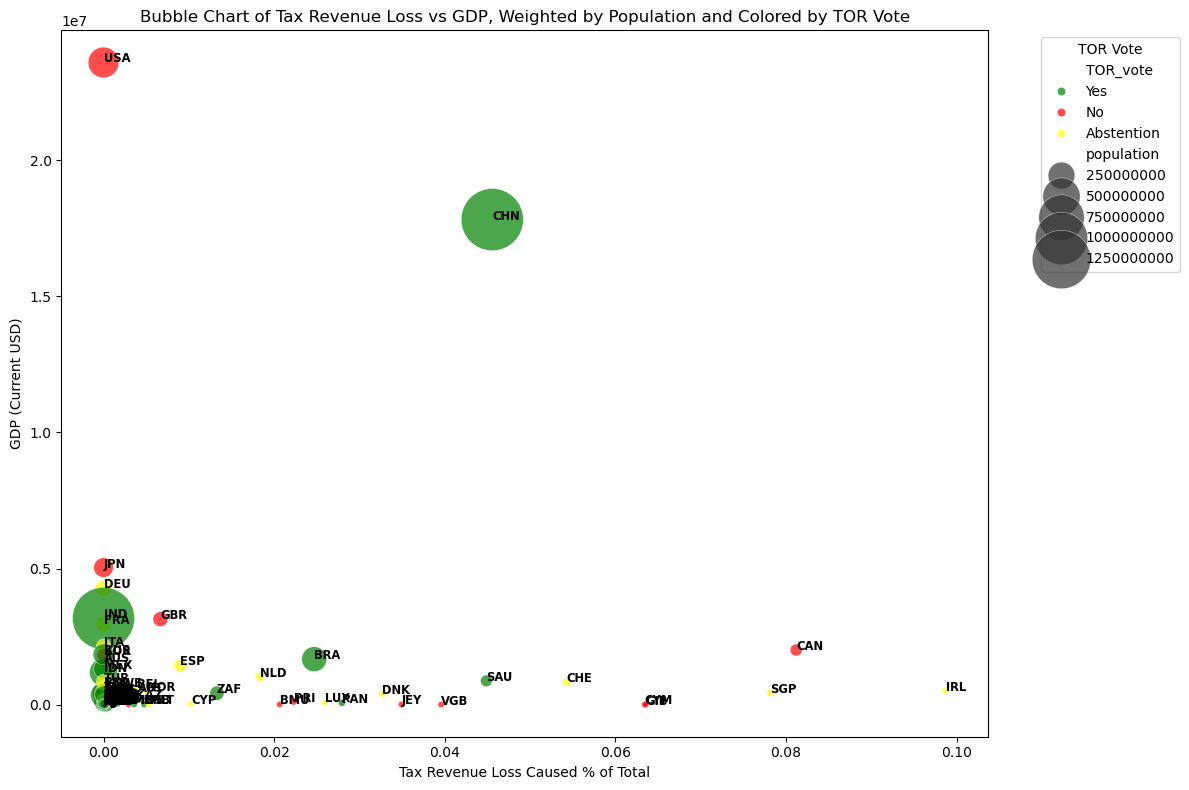

In [9]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = data_figure_conclusion.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'yellow', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='tax_revenue_loss_caused_pct_of_total',
    y='gdp_current_usd',
    size='population',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Tax Revenue Loss Caused % of Total')
plt.ylabel('GDP (Current USD)')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add annotations
for line in range(0, filtered_data.shape[0]):
    plt.text(
        filtered_data.tax_revenue_loss_caused_pct_of_total.iloc[line],
        filtered_data.gdp_current_usd.iloc[line],
        filtered_data.iso_partner.iloc[line],
        horizontalalignment='left',
        size='small',
        color='black',
        weight='semibold'
    )

# Show the plot
plt.tight_layout()
plt.show()

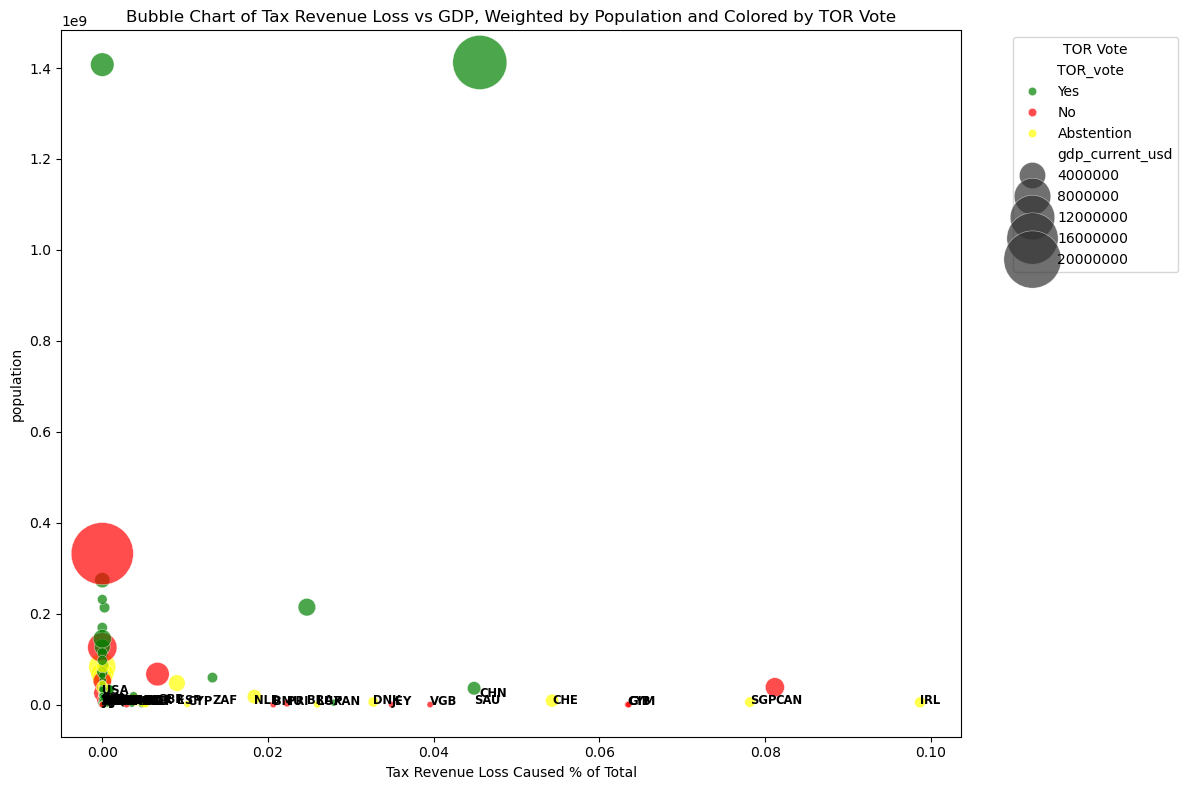

In [10]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = data_figure_conclusion.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'yellow', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='tax_revenue_loss_caused_pct_of_total',
    y='population',
    size='gdp_current_usd',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Tax Revenue Loss Caused % of Total')
plt.ylabel('population')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add annotations
for line in range(0, filtered_data.shape[0]):
    plt.text(
        filtered_data.tax_revenue_loss_caused_pct_of_total.iloc[line],
        filtered_data.gdp_current_usd.iloc[line],
        filtered_data.iso_partner.iloc[line],
        horizontalalignment='left',
        size='small',
        color='black',
        weight='semibold'
    )

# Show the plot
plt.tight_layout()
plt.show()

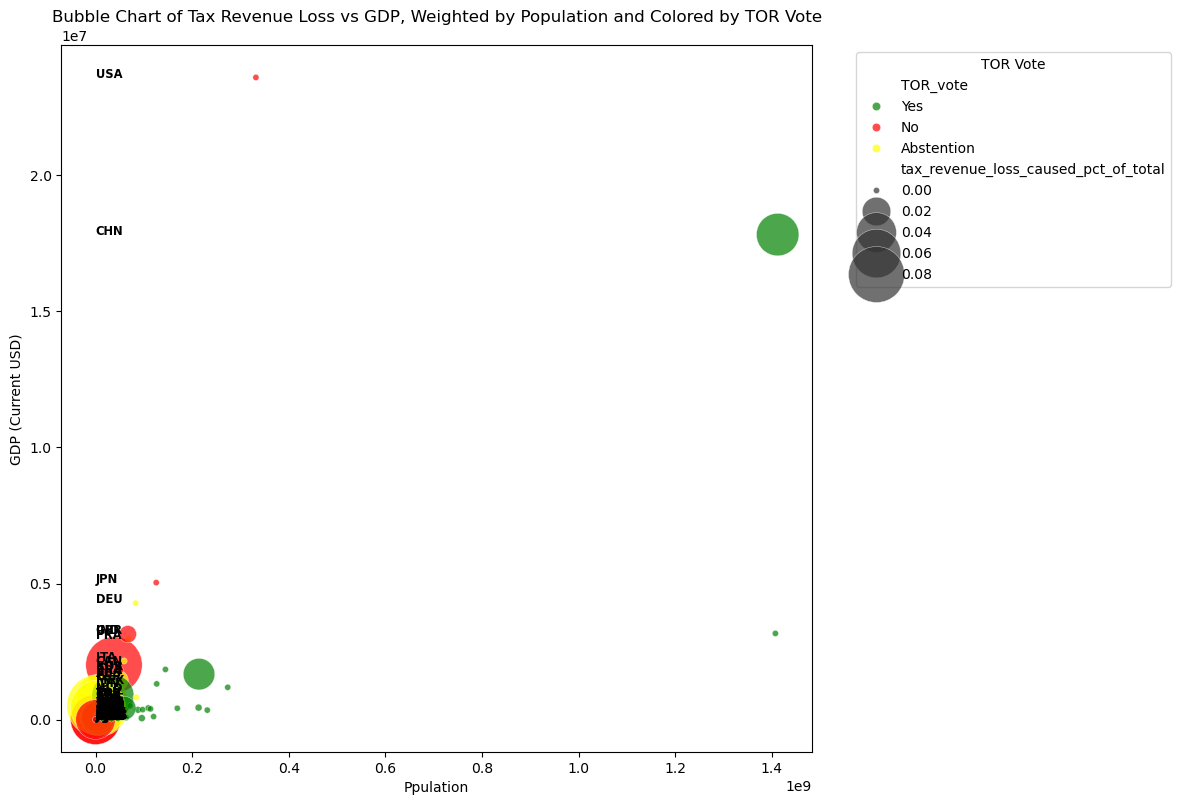

In [11]:
# Assuming killer_graph_data is your DataFrame
# Filter out rows with NaN values in the relevant columns
filtered_data = data_figure_conclusion.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'gdp_current_usd', 'population', 'TOR_vote'])

# Define a custom color palette
custom_palette = {'Yes': 'green', 'Abstention': 'yellow', 'No': 'red'}

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='population',
    y='gdp_current_usd',
    size='tax_revenue_loss_caused_pct_of_total',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette=custom_palette,  # Use the custom color palette
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('Ppulation')
plt.ylabel('GDP (Current USD)')
plt.title('Bubble Chart of Tax Revenue Loss vs GDP, Weighted by Population and Colored by TOR Vote')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add annotations
for line in range(0, filtered_data.shape[0]):
    plt.text(
        filtered_data.tax_revenue_loss_caused_pct_of_total.iloc[line],
        filtered_data.gdp_current_usd.iloc[line],
        filtered_data.iso_partner.iloc[line],
        horizontalalignment='left',
        size='small',
        color='black',
        weight='semibold'
    )

# Show the plot
plt.tight_layout()
plt.show()

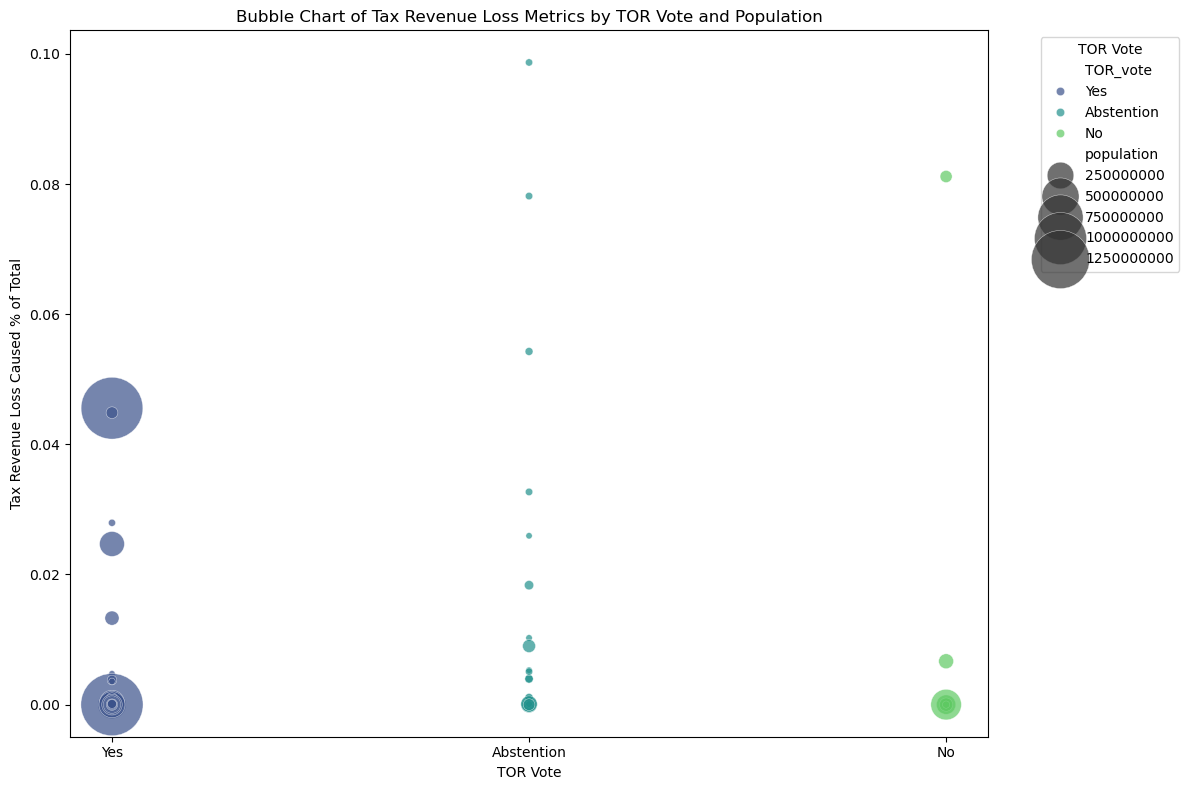

In [12]:
# Filter out rows with NaN values in the relevant columns
filtered_data = sotj_tor_data_2021.dropna(subset=['tax_revenue_loss_caused_pct_of_total', 'TOR_vote', 'population'])

# Create the bubble chart
plt.figure(figsize=(12, 8))
bubble_chart = sns.scatterplot(
    data=filtered_data,
    x='TOR_vote',
    y='tax_revenue_loss_caused_pct_of_total',
    size='population',
    sizes=(20, 2000),  # Adjust the range of bubble sizes
    hue='TOR_vote',
    palette='viridis',  # You can choose a different color palette if you prefer
    alpha=0.7  # Transparency of the points
)

# Add labels and title
plt.xlabel('TOR Vote')
plt.ylabel('Tax Revenue Loss Caused % of Total')
plt.title('Bubble Chart of Tax Revenue Loss Metrics by TOR Vote and Population')
plt.legend(title='TOR Vote', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()